In [8]:
pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn streamlit joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\miche\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def prepare_lol_data(filepath):
    df = pd.read_csv(filepath)
    
    df['blueKDA'] = (df['blueKills'] + df['blueAssists']) / (df['blueDeaths'] + 1)
    df['redKDA'] = (df['redKills'] + df['redAssists']) / (df['redDeaths'] + 1)
    
    df['blueGoldPerKill'] = df['blueTotalGold'] / (df['blueKills'] + 1)
    df['blueXPPerMin'] = df['blueTotalExperience'] / 10
    
    df['blueTotalObjectives'] = df['blueDragons'] + df['blueHeralds'] + df['blueTowersDestroyed']
    df['redTotalObjectives'] = df['redDragons'] + df['redHeralds'] + df['redTowersDestroyed']
    
    df['blueSnowballFactor'] = df['blueGoldDiff'] / (df['blueKills'] + 1)
    
    cols_to_drop = ['gameId', 'blueWardsPlaced', 'blueWardsDestroyed', 'redWardsPlaced', 'redWardsDestroyed']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
    
    return df

data = prepare_lol_data('../data/high_diamond_ranked_10min.csv')

Format du dataset : (9879, 42)
['blueWins', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueEliteMonsters', 'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff', 'blueCSPerMin', 'blueGoldPerMin', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed', 'redTotalGold', 'redAvgLevel', 'redTotalExperience', 'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff', 'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin', 'blueKDA', 'redKDA', 'blueGoldPerKill', 'blueXPPerMin', 'blueTotalObjectives', 'redTotalObjectives', 'blueSnowballFactor']
<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 42 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  ----

C:\Users\miche\AppData\Local\Temp\ipykernel_22440\1687175804.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='blueWins', data=df, palette='viridis')


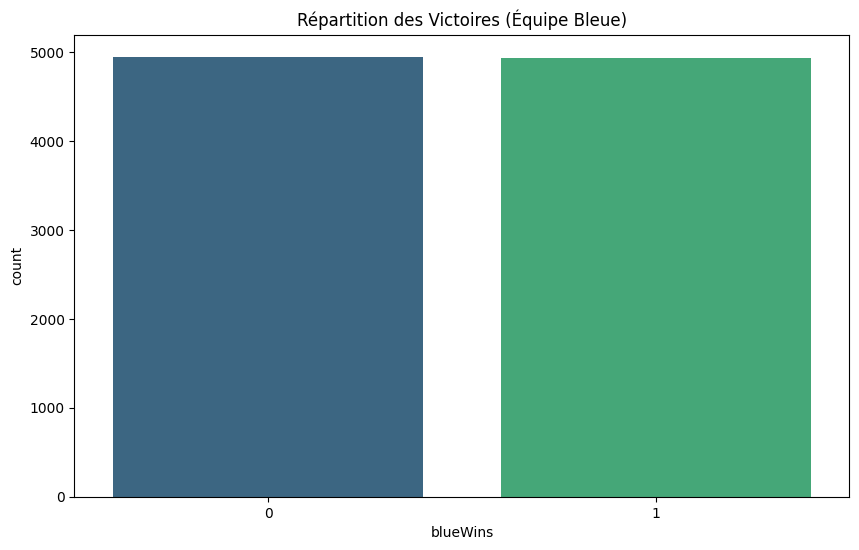

Top 15 des variables les plus corrélées à la victoire :
blueWins               1.000000
blueGoldDiff           0.511119
redGoldDiff            0.511119
redExperienceDiff      0.489558
blueExperienceDiff     0.489558
blueTotalGold          0.417213
blueGoldPerMin         0.417213
redTotalGold           0.411396
redGoldPerMin          0.411396
blueSnowballFactor     0.410631
blueTotalExperience    0.396141
blueXPPerMin           0.396141
redTotalExperience     0.387588
blueKDA                0.374163
redKDA                 0.373789
Name: blueWins, dtype: float64


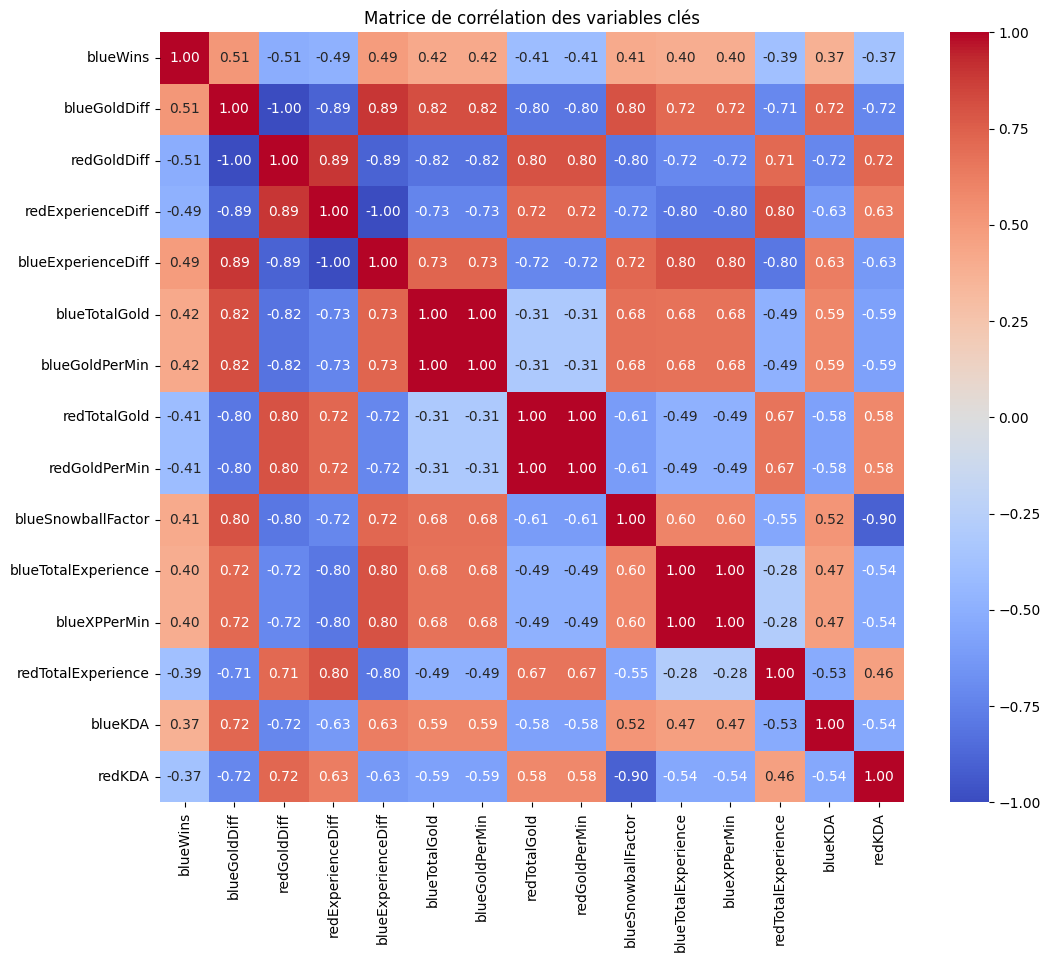

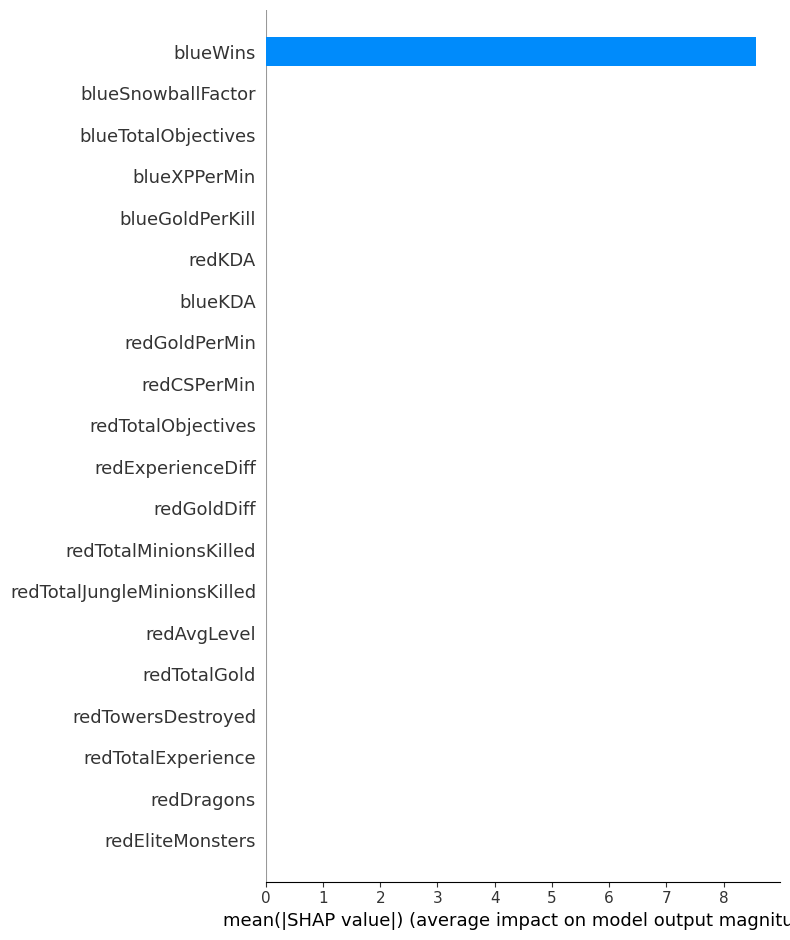

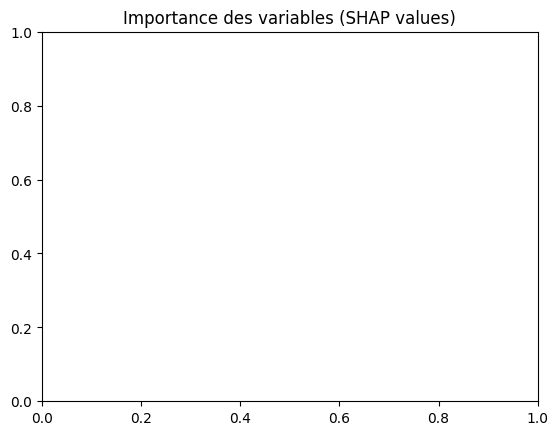

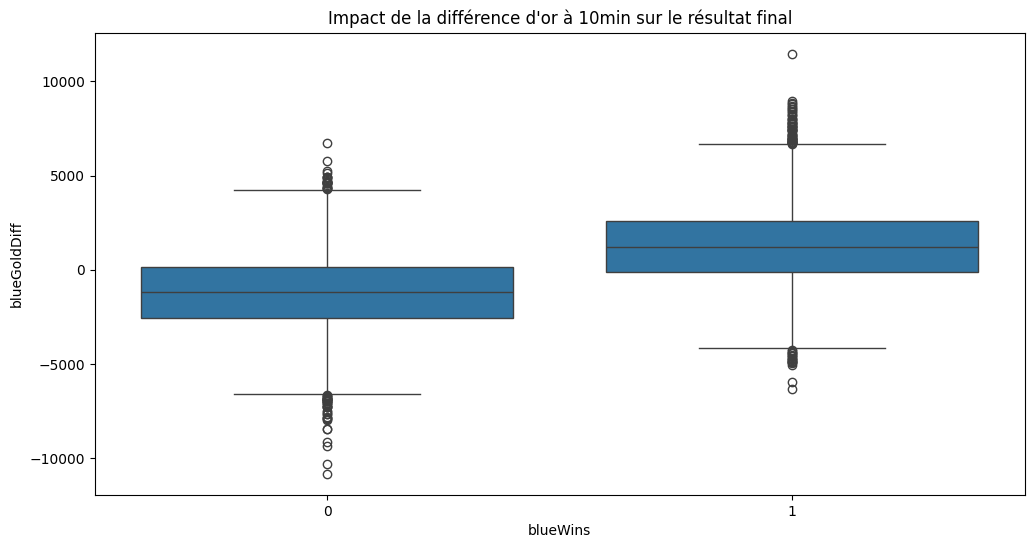

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

df = data

print(f"Format du dataset : {df.shape}")
print(df.columns.tolist())
df.head()

df.info()
df.describe().T

plt.figure(figsize=(10, 6))
sns.countplot(x='blueWins', data=df, palette='viridis')
plt.title('Répartition des Victoires (Équipe Bleue)')
plt.show()

corr_matrix = df.corr()
top_features = corr_matrix['blueWins'].abs().sort_values(ascending=False).head(15)
print("Top 15 des variables les plus corrélées à la victoire :")
print(top_features)

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation des variables clés')
plt.show()

X = df
y = df['blueWins']

model_importance = xgb.XGBClassifier(random_state=42)
model_importance.fit(X, y)

explainer = shap.TreeExplainer(model_importance)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X, plot_type="bar")
plt.title('Importance des variables (SHAP values)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='blueWins', y='blueGoldDiff', data=df)
plt.title('Impact de la différence d\'or à 10min sur le résultat final')
plt.show()

In [10]:
df.columns


Index(['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed',
       'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists',
       'blueEliteMonsters', 'blueDragons', 'blueHeralds',
       'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel',
       'blueTotalExperience', 'blueTotalMinionsKilled',
       'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff',
       'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed',
       'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
       'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed',
       'redTotalGold', 'redAvgLevel', 'redTotalExperience',
       'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff',
       'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'],
      dtype='str')

Format du dataset : (9879, 40)
['gameId', 'blueWins', 'blueWardsPlaced', 'blueWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueEliteMonsters', 'blueDragons', 'blueHeralds', 'blueTowersDestroyed', 'blueTotalGold', 'blueAvgLevel', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueGoldDiff', 'blueExperienceDiff', 'blueCSPerMin', 'blueGoldPerMin', 'redWardsPlaced', 'redWardsDestroyed', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed', 'redTotalGold', 'redAvgLevel', 'redTotalExperience', 'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redGoldDiff', 'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin']
<class 'pandas.DataFrame'>
RangeIndex: 9879 entries, 0 to 9878
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   gameId                  

C:\Users\miche\AppData\Local\Temp\ipykernel_24816\406556375.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='blueWins', data=df, palette='viridis')


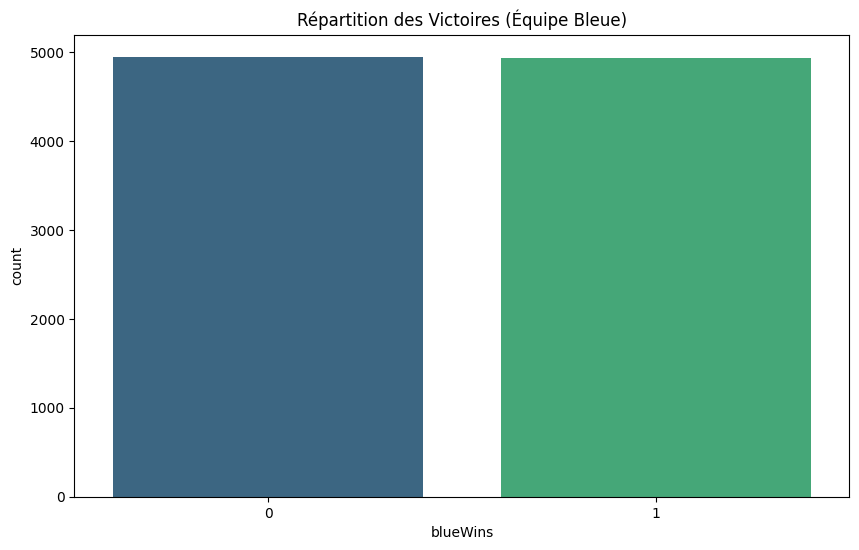

Top 15 des variables les plus corrélées à la victoire :
blueWins               1.000000
blueGoldDiff           0.511119
redGoldDiff            0.511119
redExperienceDiff      0.489558
blueExperienceDiff     0.489558
blueTotalGold          0.417213
blueGoldPerMin         0.417213
redTotalGold           0.411396
redGoldPerMin          0.411396
blueTotalExperience    0.396141
redTotalExperience     0.387588
blueAvgLevel           0.357820
redAvgLevel            0.352127
redKills               0.339297
blueDeaths             0.339297
Name: blueWins, dtype: float64


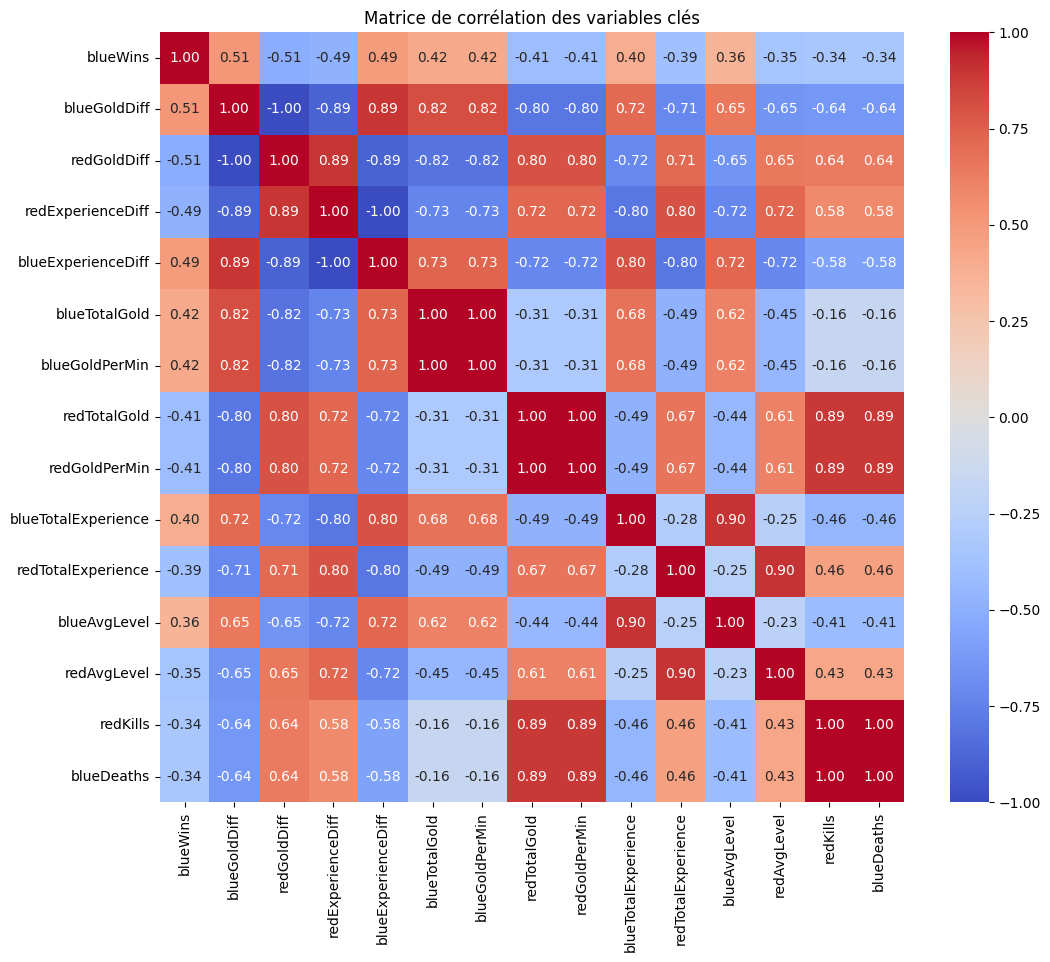

: 

: 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import shap

df = pd.read_csv('../data/high_diamond_ranked_10min.csv')

print(f"Format du dataset : {df.shape}")
print(df.columns.tolist())
df.head()

df.info()
df.describe().T

plt.figure(figsize=(10, 6))
sns.countplot(x='blueWins', data=df, palette='viridis')
plt.title('Répartition des Victoires (Équipe Bleue)')
plt.show()

corr_matrix = df.corr()
top_features = corr_matrix['blueWins'].abs().sort_values(ascending=False).head(15)
print("Top 15 des variables les plus corrélées à la victoire :")
print(top_features)

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice de corrélation des variables clés')
plt.show()

X = df.drop(columns=['gameId', 'blueWins'])
y = df['blueWins']

model_importance = RandomForestClassifier(n_estimators=100, random_state=42)
model_importance.fit(X, y)

explainer = shap.TreeExplainer(model_importance)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values[1], X, plot_type="bar")
plt.title('Importance des variables (SHAP values)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='blueWins', y='blueGoldDiff', data=df)
plt.title('Impact de la différence d\'or à 10min sur le résultat final')
plt.show()


Logistic Regression AUC: 0.8057
KNN AUC: 0.7886
XGBoost AUC: 0.8033

Modèle le plus pertinent : Logistic Regression


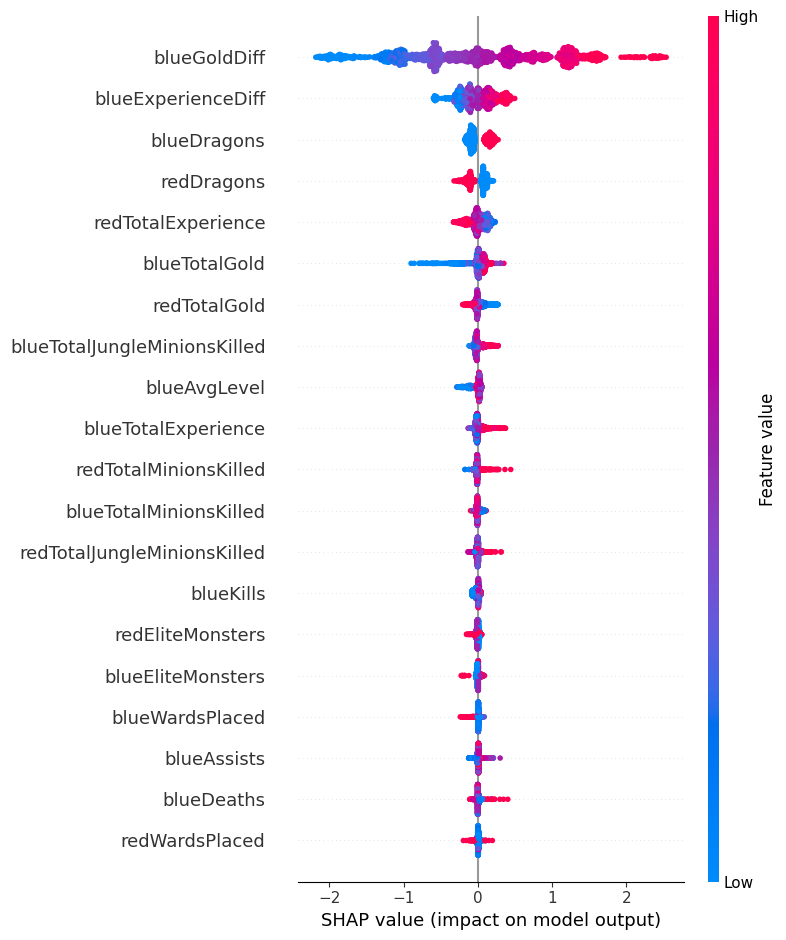

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import shap

df = pd.read_csv('../data/high_diamond_ranked_10min.csv')

drop_cols = ['gameId', 'redFirstBlood', 'redKills', 'redDeaths', 'redGoldDiff', 'redExperienceDiff']
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

X = df_clean.drop(columns=['blueWins'])
y = df_clean['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    train_data = X_train_scaled if name != "XGBoost" else X_train
    test_data = X_test_scaled if name != "XGBoost" else X_test
    
    model.fit(train_data, y_train)
    probs = model.predict_proba(test_data)[:, 1]
    auc = roc_auc_score(y_test, probs)
    results[name] = auc
    print(f"{name} AUC: {auc:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nModèle le plus pertinent : {best_model_name}")

explainer = shap.TreeExplainer(models["XGBoost"])
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, classification_report

def build_features(df):
    df_eng = df.copy()
    
    df_eng['blueKDA'] = (df_eng['blueKills'] + df_eng['blueAssists']) / (df_eng['blueDeaths'] + 1)
    df_eng['blueGoldPerKill'] = df_eng['blueTotalGold'] / (df_eng['blueKills'] + 1)
    df_eng['blueXPPerMin'] = df_eng['blueTotalExperience'] / 10
    
    df_eng['blueTotalObjectives'] = df_eng['blueDragons'] + df_eng['blueHeralds'] + df_eng['blueTowersDestroyed']
    df_eng['redTotalObjectives'] = df_eng['redDragons'] + df_eng['redHeralds'] + df_eng['redTowersDestroyed']
    
    df_eng['blueSnowballFactor'] = df_eng['blueGoldDiff'] / (df_eng['blueKills'] + 1)
    
    return df_eng

raw_data = pd.read_csv('../data/high_diamond_ranked_10min.csv')
df = build_features(raw_data)

drop_cols = [
    'gameId', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists',
    'redEliteMonsters', 'redDragons', 'redHeralds', 'redTowersDestroyed', 
    'redAvgLevel', 'redTotalGold', 'redTotalExperience', 'redTotalMinionsKilled', 
    'redTotalJungleMinionsKilled', 'redGoldDiff', 'redExperienceDiff', 
    'redCSPerMin', 'redGoldPerMin'
]

df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

X = df_clean.drop(columns=['blueWins'])
y = df_clean['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=15)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, probs)
    results[name] = auc
    print(f"{name} AUC: {auc:.4f}")

Logistic Regression AUC: 0.8062
KNN AUC: 0.7849


C:\Users\miche\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Logistic Regression AUC: 0.8061
KNN AUC: 0.7833
XGBoost AUC: 0.8059


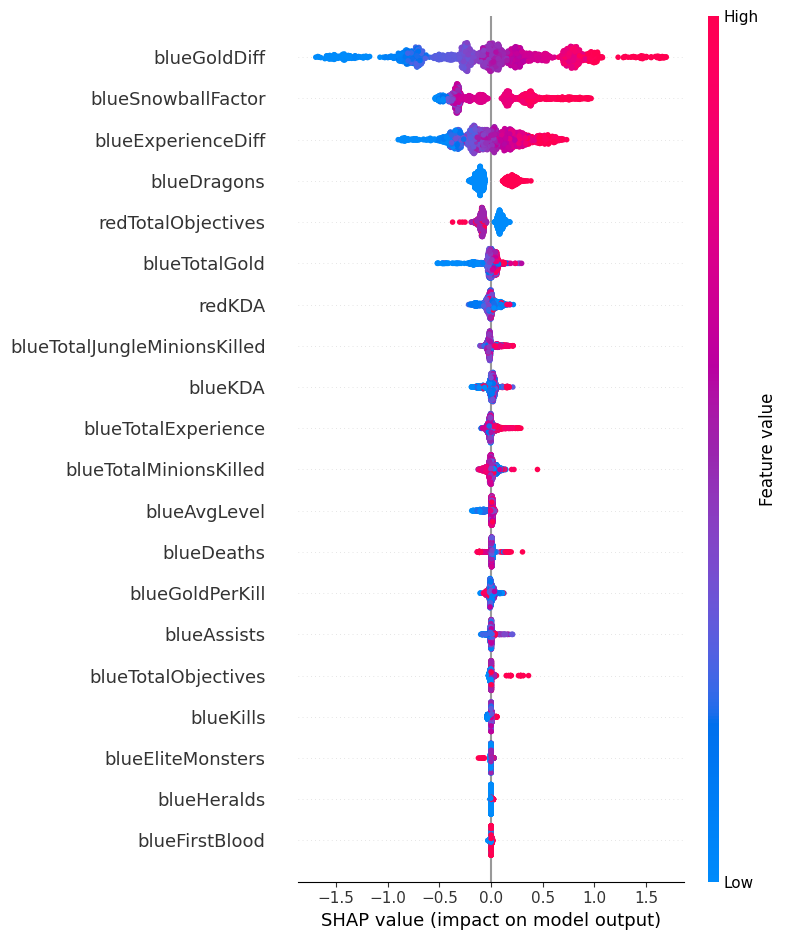

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import shap

df = data

drop_cols = [
    'gameId',
    'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 
    'redEliteMonsters', 'redDragons', 'redHeralds', 
    'redTowersDestroyed', 'redTotalGold', 'redAvgLevel', 
    'redTotalExperience', 'redTotalMinionsKilled', 
    'redTotalJungleMinionsKilled', 'redGoldDiff', 
    'redExperienceDiff', 'redCSPerMin', 'redGoldPerMin'
]
df_clean = df.drop(columns=[c for c in drop_cols if c in df.columns])

X = df_clean.drop(columns=['blueWins'])
y = df_clean['blueWins']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=15),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    train_data = X_train_scaled if name != "XGBoost" else X_train
    test_data = X_test_scaled if name != "XGBoost" else X_test
    
    model.fit(train_data, y_train)
    probs = model.predict_proba(test_data)[:, 1]
    auc = roc_auc_score(y_test, probs)
    results[name] = auc
    print(f"{name} AUC: {auc:.4f}")

best_model = models["XGBoost"]
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test)